# Census Income Prediction using Machine Learning
### Knowledge Discovery and Data Mining

**Authors:** Emad Kalantari
**Dataset:** [UCI Adult (Census Income)](https://archive.ics.uci.edu/dataset/20/census+income) — 48 842 instances, 14 features  
**Task:** Binary classification — predict whether an individual earns **>\$50K/yr**

---

## Project Overview

This notebook follows the full **KDD pipeline**:

| Stage | Description |
|---|---|
| **Data Loading** | Fetch directly from UCI ML Repository via `ucimlrepo` |
| **Data Cleaning** | Normalise labels, handle missing values |
| **EDA** | Descriptive stats, gender-income chart, correlation heatmap, age distribution |
| **Preprocessing** | MinMax scaling, one-hot encoding, label encoding |
| **Modelling** | Logistic Regression · Random Forest · XGBoost |
| **Hyperparameter Tuning** | Grid sweep on key parameters per model |
| **Evaluation** | Accuracy, MSE, RMSE, R², Precision, Recall, F1, Confusion Matrix |

---

## 0 · Setup
Install the dataset-fetching library and import all dependencies used throughout the notebook.

In [1]:
# Install UCI dataset fetcher (safe to re-run)
!pip install ucimlrepo --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ── Standard library ──────────────────────────────────────────────────────────
from math import sqrt

# ── Data & plotting ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ── Scikit-learn ───────────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# ── XGBoost ────────────────────────────────────────────────────────────────────
from xgboost import XGBClassifier

# ── Dataset fetcher ────────────────────────────────────────────────────────────
from ucimlrepo import fetch_ucirepo

# ── Notebook display settings ─────────────────────────────────────────────────
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.4f}".format)
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

print("All libraries loaded successfully.")

All libraries loaded successfully.


---
## 1 · Data Loading

The dataset is fetched programmatically from the UCI ML Repository — no manual download required.  
It contains **14 features** (6 numerical, 8 categorical) and a binary target: `income` (≤50K / >50K).

In [3]:
# Fetch Census Income dataset (UCI id = 20)
census_income = fetch_ucirepo(id=20)

# Combine features and target into a single DataFrame
df = pd.concat([census_income.data.features, census_income.data.targets], axis=1)

print(f"Dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Target classes: {df['income'].unique()}")
df.head()

Dataset shape : 48,842 rows × 15 columns
Target classes: <StringArray>
['<=50K', '>50K', '<=50K.', '>50K.']
Length: 4, dtype: str


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


---
## 2 · Data Exploration

Before cleaning, we inspect the raw data: data types, value counts, and missing values.

In [4]:
print("── Column types ─────────────────────────────────────────────────────")
print(df.dtypes.to_string())

── Column types ─────────────────────────────────────────────────────
age               int64
workclass           str
fnlwgt            int64
education           str
education-num     int64
marital-status      str
occupation          str
relationship        str
race                str
sex                 str
capital-gain      int64
capital-loss      int64
hours-per-week    int64
native-country      str
income              str


In [5]:
print("── Missing values per column ────────────────────────────────────────")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
      .query("`Missing Count` > 0").to_string())

── Missing values per column ────────────────────────────────────────
                Missing Count  Missing %
workclass                 963     1.9700
occupation                966     1.9800
native-country            274     0.5600


In [6]:
print("── Target class distribution (raw) ─────────────────────────────────")
print(df["income"].value_counts(dropna=False).to_string())

── Target class distribution (raw) ─────────────────────────────────
income
<=50K     24720
<=50K.    12435
>50K       7841
>50K.      3846


---
## 3 · Data Cleaning

Two issues are addressed:
1. **Inconsistent target labels** — the training split uses `<=50K` while the test split appends a period (`<=50K.`). We strip whitespace and trailing periods.
2. **Missing values** — rows with any NaN are dropped (~2.5% of data). Given that missingness is concentrated in only 3 columns and the dataset is large, list-wise deletion is appropriate here.

In [7]:
# ── Fix target labels ─────────────────────────────────────────────────────────
df["income"] = df["income"].str.strip().str.rstrip(".")

print("Target labels after normalisation:", df["income"].unique())

# ── Drop rows with missing values ──────────────────────────────────────────────
n_before = len(df)
df = df.dropna().reset_index(drop=True)
n_dropped = n_before - len(df)

print(f"Rows before cleaning : {n_before:,}")
print(f"Rows dropped (NaN)   : {n_dropped:,}  ({n_dropped/n_before*100:.1f}%)")
print(f"Rows after cleaning  : {len(df):,}")

Target labels after normalisation: <StringArray>
['<=50K', '>50K']
Length: 2, dtype: str
Rows before cleaning : 48,842
Rows dropped (NaN)   : 1,221  (2.5%)
Rows after cleaning  : 47,621


---
## 4 · Exploratory Data Analysis (EDA)

We explore the cleaned data through descriptive statistics and targeted visualisations to understand distributions, class balance, and feature relationships.

### 4.1 · Descriptive Statistics

In [8]:
NUMERICAL  = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
CATEGORICAL = ["workclass", "education", "marital-status", "occupation",
                "relationship", "race", "sex", "native-country"]

print("── Numerical feature statistics ─────────────────────────────────────")
df[NUMERICAL].describe().round(2)

── Numerical feature statistics ─────────────────────────────────────


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,47621.0000,47621.0000,47621.0000,47621.0000,47621.0000,47621.0000
mean,38.6400,189727.1400,10.0900,1091.1400,87.8500,40.6000
std,13.5600,105569.4700,2.5700,7487.2300,404.0100,12.2600
min,17.0000,12285.0000,1.0000,0.0000,0.0000,1.0000
25%,28.0000,117584.0000,9.0000,0.0000,0.0000,40.0000
50%,37.0000,178282.0000,10.0000,0.0000,0.0000,40.0000
75%,48.0000,237720.0000,12.0000,0.0000,0.0000,45.0000
max,90.0000,1490400.0000,16.0000,99999.0000,4356.0000,99.0000


### 4.2 · Income Distribution by Gender

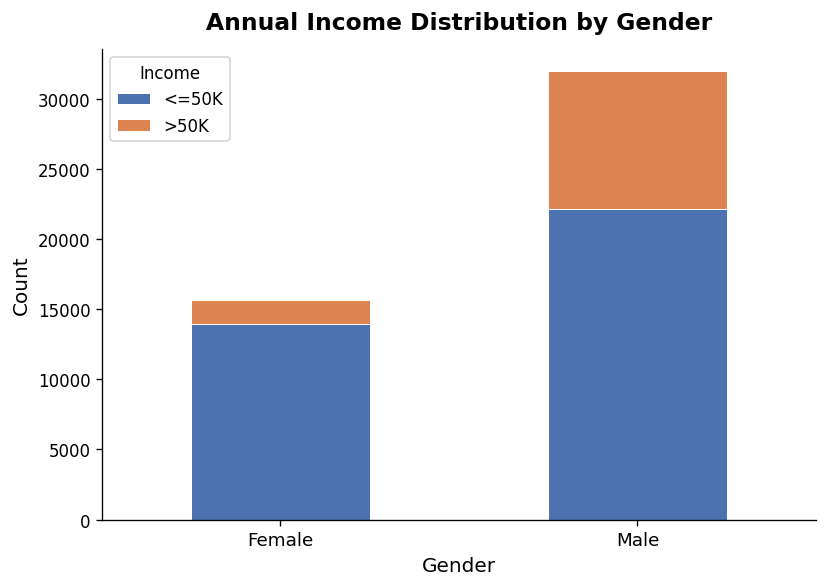

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))

contingency = pd.crosstab(df["sex"], df["income"])
contingency.plot(kind="bar", stacked=True, ax=ax,
                 color=["#4C72B0", "#DD8452"], edgecolor="white", linewidth=0.6)

ax.set_title("Annual Income Distribution by Gender", fontsize=14, pad=12, fontweight="bold")
ax.set_xlabel("Gender", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=11)
ax.legend(title="Income", fontsize=10)
plt.tight_layout()
plt.show()

### 4.3 · Correlation Matrix — Numerical Features

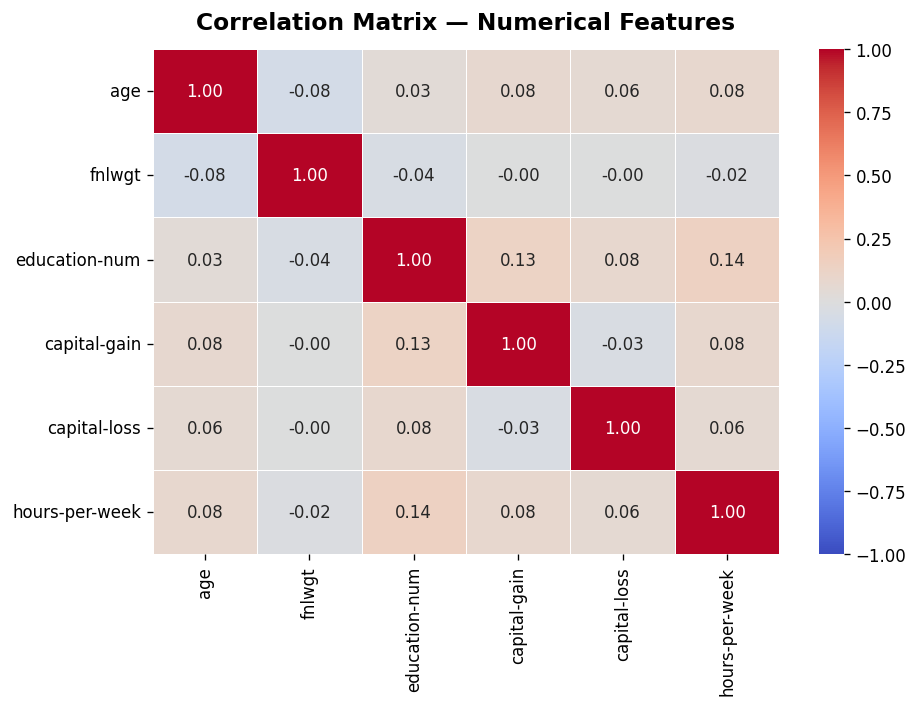

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

corr = df[NUMERICAL].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)   # show lower triangle only

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)

ax.set_title("Correlation Matrix — Numerical Features", fontsize=14, pad=12, fontweight="bold")
plt.tight_layout()
plt.show()

### 4.4 · Age Distribution by Income Class

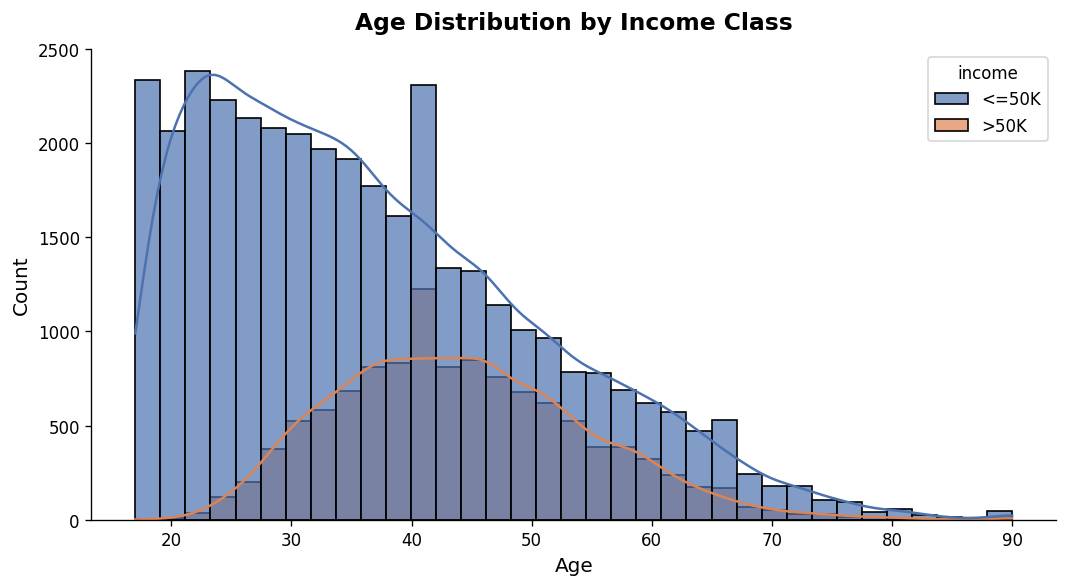

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(data=df, x="age", hue="income", kde=True,
             palette={"<=50K": "#4C72B0", ">50K": "#DD8452"},
             bins=35, alpha=0.7, ax=ax)

ax.set_title("Age Distribution by Income Class", fontsize=14, pad=12, fontweight="bold")
ax.set_xlabel("Age", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

---
## 5 · Data Preprocessing

Three steps transform the cleaned data into a model-ready feature matrix:

1. **MinMaxScaler** — scale numerical features to [0, 1] so magnitude differences don't distort distance-based or regularised models.
2. **One-hot encoding** (`pd.get_dummies`, `drop_first=True`) — convert categorical features to numeric dummies, dropping the first level to avoid multicollinearity.
3. **LabelEncoder** — map the binary target `<=50K` → 0, `>50K` → 1.

In [12]:
# Work on a copy so the raw DataFrame is preserved
df_proc = df.copy()

# ── 1. Scale numerical features ───────────────────────────────────────────────
scaler = MinMaxScaler()
df_proc[NUMERICAL] = scaler.fit_transform(df_proc[NUMERICAL])

# ── 2. One-hot encode categorical features ─────────────────────────────────────
df_proc = pd.get_dummies(df_proc, columns=CATEGORICAL, drop_first=True)

# ── 3. Encode target ──────────────────────────────────────────────────────────
le = LabelEncoder()
y_raw = df_proc.pop("income")
Y = le.fit_transform(y_raw)          # <=50K → 0,  >50K → 1
X = df_proc

print(f"Feature matrix shape : {X.shape}")
print(f"Target distribution  : 0 (≤50K) = {(Y==0).sum():,}  |  1 (>50K) = {(Y==1).sum():,}")
print(f"Class imbalance ratio: {(Y==0).sum()/(Y==1).sum():.2f}:1")

Feature matrix shape : (47621, 100)
Target distribution  : 0 (≤50K) = 36,080  |  1 (>50K) = 11,541
Class imbalance ratio: 3.13:1


---
## 6 · Train / Test Split

A **stratified** 70 / 30 split ensures both sets reflect the same class distribution as the full dataset.

In [13]:
RANDOM_STATE = 42
TEST_SIZE    = 0.30

X_train, X_test, y_train, y_test = train_test_split(
    X, Y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=Y,
)

print(f"Training set : {len(X_train):,} samples")
print(f"Test set     : {len(X_test):,} samples")

Training set : 33,334 samples
Test set     : 14,287 samples


---
## 7 · Model Training & Evaluation

A shared helper function computes all evaluation metrics and renders the confusion matrix consistently for each model.

In [14]:
def evaluate(model_name, y_true, y_pred):
    """Print metrics and render a confusion matrix for one model."""
    acc   = accuracy_score(y_true, y_pred)
    mse   = mean_squared_error(y_true, y_pred)
    rmse  = sqrt(mse)
    r2    = r2_score(y_true, y_pred)
    prec  = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec   = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1    = f1_score(y_true, y_pred, average="macro")

    print(f"{'─'*45}")
    print(f"  {model_name}")
    print(f"{'─'*45}")
    print(f"  Accuracy  : {acc:.5f}")
    print(f"  MSE       : {mse:.5f}")
    print(f"  RMSE      : {rmse:.5f}")
    print(f"  R² Score  : {r2:.5f}")
    print(f"  Precision : {prec:.5f}")
    print(f"  Recall    : {rec:.5f}")
    print(f"  F1 Score  : {f1:.5f}")

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["≤50K", ">50K"])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Confusion Matrix — {model_name}", fontsize=12, pad=10, fontweight="bold")
    plt.tight_layout()
    plt.show()

    return dict(Model=model_name, Accuracy=round(acc,5), MSE=round(mse,5),
                RMSE=round(rmse,5), R2=round(r2,5), Precision=round(prec,5),
                Recall=round(rec,5), F1=round(f1,5))

results = []   # collect per-model dicts for the final comparison table
print("Evaluation helper ready.")

Evaluation helper ready.


### 7.1 · Logistic Regression

#### Hyperparameter Sensitivity — Regularisation Parameter *C*
We sweep `C ∈ {0.01, 0.1, 1, 10, 100}`.  
Higher *C* means less regularisation. We expect accuracy to plateau once the model is sufficiently unconstrained.

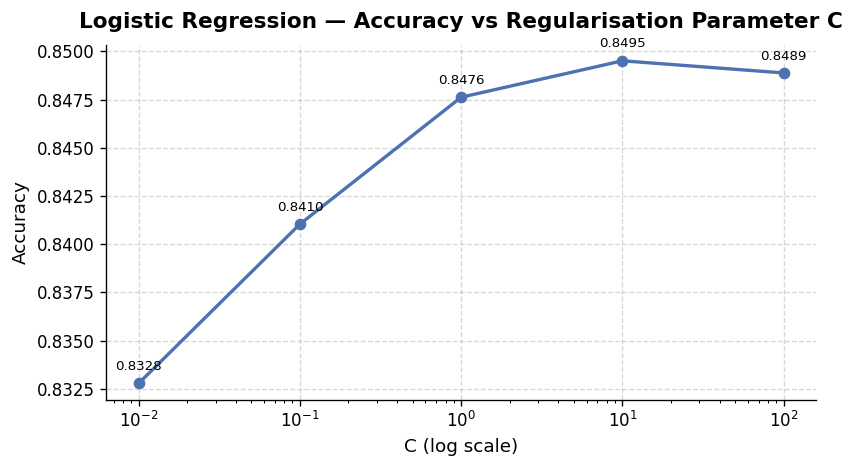

Best C = 10  →  Accuracy = 0.84951


In [15]:
C_values = [0.01, 0.1, 1, 10, 100]
lr_accuracies = []

for C in C_values:
    lr = LogisticRegression(C=C, max_iter=1000, random_state=RANDOM_STATE)
    lr.fit(X_train, y_train)
    lr_accuracies.append(accuracy_score(y_test, lr.predict(X_test)))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(C_values, lr_accuracies, marker="o", linewidth=2, color="#4C72B0")
ax.set_xscale("log")
ax.set_title("Logistic Regression — Accuracy vs Regularisation Parameter C",
             fontsize=13, pad=10, fontweight="bold")
ax.set_xlabel("C (log scale)", fontsize=11)
ax.set_ylabel("Accuracy", fontsize=11)
ax.grid(True, linestyle="--", alpha=0.5)
for C, acc in zip(C_values, lr_accuracies):
    ax.annotate(f"{acc:.4f}", (C, acc), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=8)
plt.tight_layout()
plt.show()

best_C = C_values[lr_accuracies.index(max(lr_accuracies))]
print(f"Best C = {best_C}  →  Accuracy = {max(lr_accuracies):.5f}")

#### Final Logistic Regression — Training & Evaluation

─────────────────────────────────────────────
  Logistic Regression
─────────────────────────────────────────────
  Accuracy  : 0.84888
  MSE       : 0.15112
  RMSE      : 0.38874
  R² Score  : 0.17693
  Precision : 0.80283
  Recall    : 0.76609
  F1 Score  : 0.78145


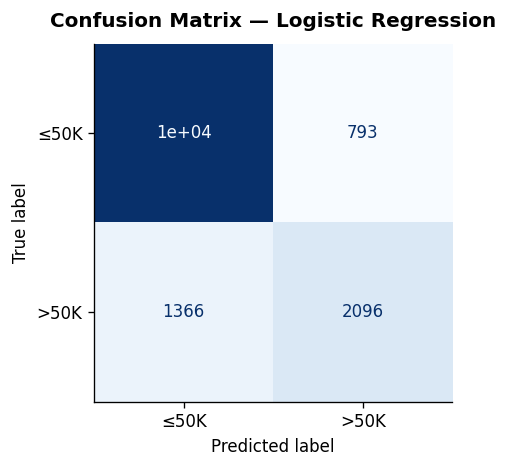

In [16]:
lr_model = LogisticRegression(C=100, max_iter=1000, random_state=RANDOM_STATE)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

results.append(evaluate("Logistic Regression", y_test, y_pred_lr))

### 7.2 · Random Forest Classifier

#### Hyperparameter Sensitivity — Number of Estimators & Max Depth

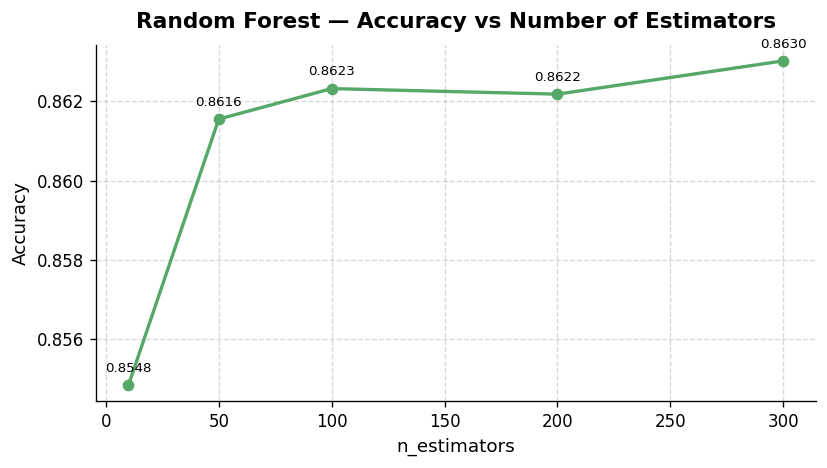

In [17]:
# ── n_estimators sweep ────────────────────────────────────────────────────────
n_est_values = [10, 50, 100, 200, 300]
rf_acc_est = []

for n in n_est_values:
    rf = RandomForestClassifier(n_estimators=n, max_depth=20, random_state=RANDOM_STATE)
    rf.fit(X_train, y_train)
    rf_acc_est.append(accuracy_score(y_test, rf.predict(X_test)))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(n_est_values, rf_acc_est, marker="o", linewidth=2, color="#55A868")
ax.set_title("Random Forest — Accuracy vs Number of Estimators",
             fontsize=13, pad=10, fontweight="bold")
ax.set_xlabel("n_estimators", fontsize=11)
ax.set_ylabel("Accuracy", fontsize=11)
ax.grid(True, linestyle="--", alpha=0.5)
for n, acc in zip(n_est_values, rf_acc_est):
    ax.annotate(f"{acc:.4f}", (n, acc), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=8)
plt.tight_layout()
plt.show()

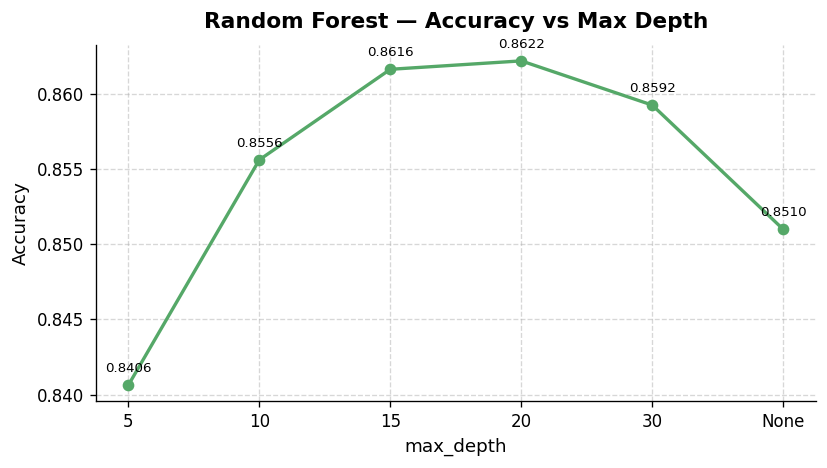

In [18]:
# ── max_depth sweep ───────────────────────────────────────────────────────────
depth_values = [5, 10, 15, 20, 30, None]
rf_acc_depth = []

for d in depth_values:
    rf = RandomForestClassifier(n_estimators=200, max_depth=d, random_state=RANDOM_STATE)
    rf.fit(X_train, y_train)
    rf_acc_depth.append(accuracy_score(y_test, rf.predict(X_test)))

labels = [str(d) if d is not None else "None" for d in depth_values]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(len(labels)), rf_acc_depth, marker="o", linewidth=2, color="#55A868")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=10)
ax.set_title("Random Forest — Accuracy vs Max Depth",
             fontsize=13, pad=10, fontweight="bold")
ax.set_xlabel("max_depth", fontsize=11)
ax.set_ylabel("Accuracy", fontsize=11)
ax.grid(True, linestyle="--", alpha=0.5)
for i, acc in enumerate(rf_acc_depth):
    ax.annotate(f"{acc:.4f}", (i, acc), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=8)
plt.tight_layout()
plt.show()

#### Final Random Forest — Training & Evaluation

─────────────────────────────────────────────
  Random Forest
─────────────────────────────────────────────
  Accuracy  : 0.86218
  MSE       : 0.13782
  RMSE      : 0.37124
  R² Score  : 0.24936
  Precision : 0.83242
  Recall    : 0.77074
  F1 Score  : 0.79423


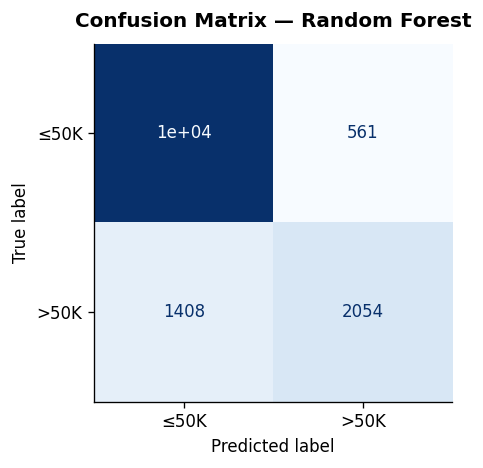

In [19]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=RANDOM_STATE)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

results.append(evaluate("Random Forest", y_test, y_pred_rf))

### 7.3 · XGBoost Classifier

#### Hyperparameter Sensitivity — Learning Rate & Number of Trees

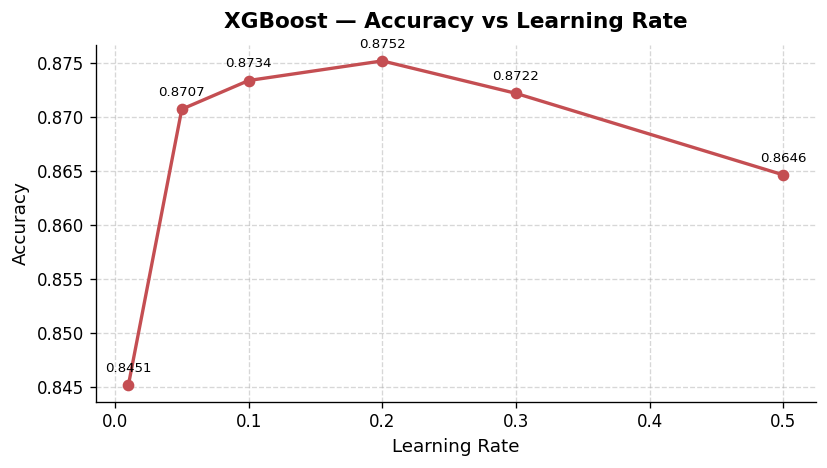

In [20]:
# ── Learning rate sweep ───────────────────────────────────────────────────────
lr_values = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5]
xgb_acc_lr = []

for lr in lr_values:
    xgb = XGBClassifier(learning_rate=lr, n_estimators=100,
                        eval_metric="logloss", random_state=RANDOM_STATE)
    xgb.fit(X_train, y_train)
    xgb_acc_lr.append(accuracy_score(y_test, xgb.predict(X_test)))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(lr_values, xgb_acc_lr, marker="o", linewidth=2, color="#C44E52")
ax.set_title("XGBoost — Accuracy vs Learning Rate",
             fontsize=13, pad=10, fontweight="bold")
ax.set_xlabel("Learning Rate", fontsize=11)
ax.set_ylabel("Accuracy", fontsize=11)
ax.grid(True, linestyle="--", alpha=0.5)
for lr, acc in zip(lr_values, xgb_acc_lr):
    ax.annotate(f"{acc:.4f}", (lr, acc), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=8)
plt.tight_layout()
plt.show()

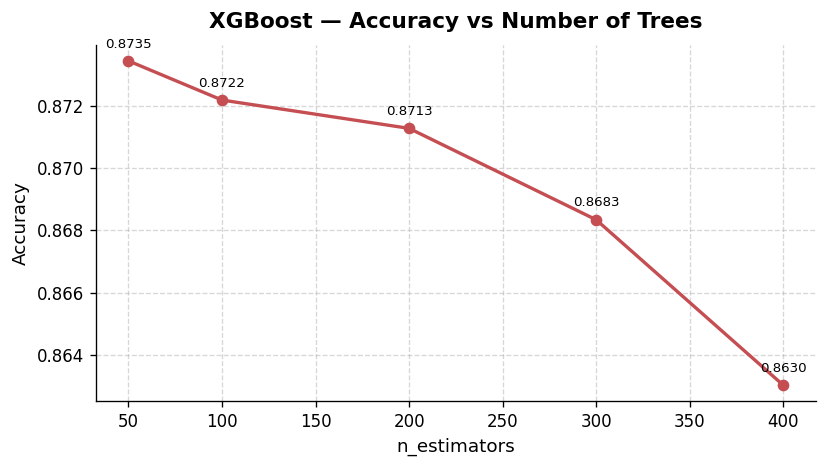

In [21]:
# ── n_estimators sweep ────────────────────────────────────────────────────────
tree_values = [50, 100, 200, 300, 400]
xgb_acc_trees = []

for n in tree_values:
    xgb = XGBClassifier(learning_rate=0.30, n_estimators=n,
                        eval_metric="logloss", random_state=RANDOM_STATE)
    xgb.fit(X_train, y_train)
    xgb_acc_trees.append(accuracy_score(y_test, xgb.predict(X_test)))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(tree_values, xgb_acc_trees, marker="o", linewidth=2, color="#C44E52")
ax.set_title("XGBoost — Accuracy vs Number of Trees",
             fontsize=13, pad=10, fontweight="bold")
ax.set_xlabel("n_estimators", fontsize=11)
ax.set_ylabel("Accuracy", fontsize=11)
ax.grid(True, linestyle="--", alpha=0.5)
for n, acc in zip(tree_values, xgb_acc_trees):
    ax.annotate(f"{acc:.4f}", (n, acc), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=8)
plt.tight_layout()
plt.show()

#### Final XGBoost — Training & Evaluation

─────────────────────────────────────────────
  XGBoost
─────────────────────────────────────────────
  Accuracy  : 0.87219
  MSE       : 0.12781
  RMSE      : 0.35750
  R² Score  : 0.30388
  Precision : 0.83738
  Recall    : 0.80033
  F1 Score  : 0.81621


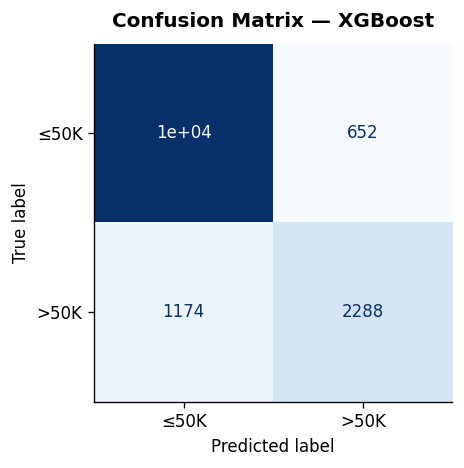

In [22]:
xgb_model = XGBClassifier(learning_rate=0.30, n_estimators=100,
                          eval_metric="logloss", random_state=RANDOM_STATE)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

results.append(evaluate("XGBoost", y_test, y_pred_xgb))

---
## 8 · Model Comparison

Side-by-side summary of all evaluation metrics across the three models.

In [23]:
results_df = pd.DataFrame(results).set_index("Model")

# Highlight the best value in each column
styled = (
    results_df.style
    .highlight_max(axis=0, color="#d4edda")
    .format("{:.5f}")
    .set_caption("Model Performance Comparison — Test Set")
)
styled

,Accuracy,MSE,RMSE,R2,Precision,Recall,F1
Model,,,,,,,
Logistic Regression,0.84888,0.15112,0.38874,0.17693,0.80283,0.76609,0.78145
Random Forest,0.86218,0.13782,0.37124,0.24936,0.83242,0.77074,0.79423
XGBoost,0.87219,0.12781,0.35750,0.30388,0.83738,0.80033,0.81621


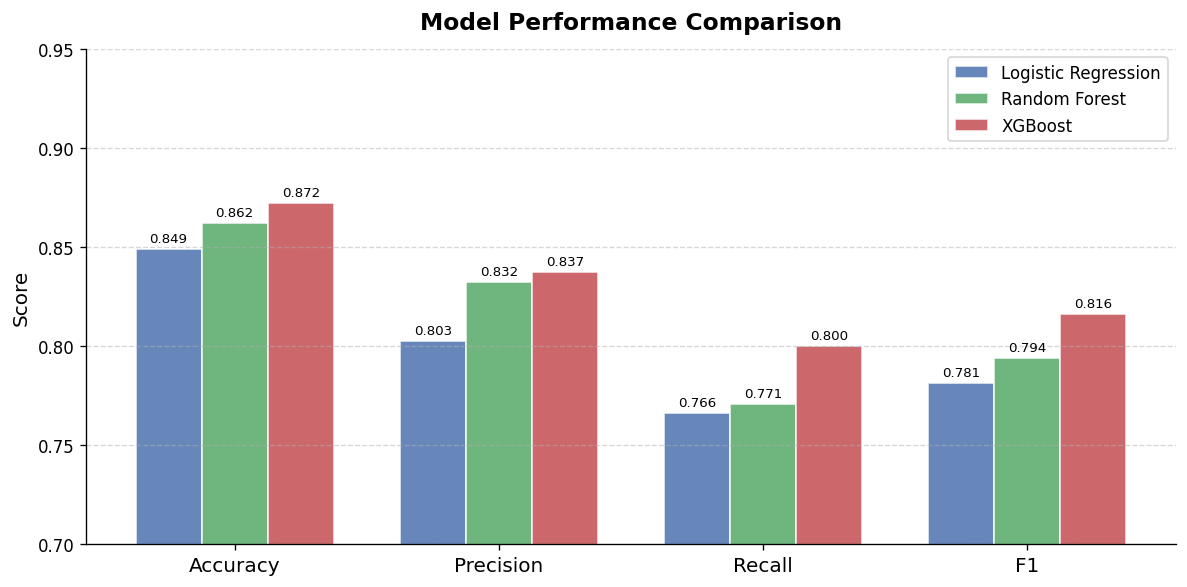


✔  Best model: XGBoost — Accuracy 0.87219  |  F1 0.81621


In [24]:
# ── Visual bar chart comparison ───────────────────────────────────────────────
metrics  = ["Accuracy", "Precision", "Recall", "F1"]
x        = np.arange(len(metrics))
width    = 0.25
colors   = ["#4C72B0", "#55A868", "#C44E52"]
names    = results_df.index.tolist()

fig, ax = plt.subplots(figsize=(10, 5))
for i, (name, color) in enumerate(zip(names, colors)):
    vals = [results_df.loc[name, m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=name,
                  color=color, alpha=0.85, edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0.70, 0.95)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Model Performance Comparison", fontsize=14, pad=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

best = results_df["Accuracy"].idxmax()
print(f"\n✔  Best model: {best} — Accuracy {results_df.loc[best,'Accuracy']:.5f}  |  F1 {results_df.loc[best,'F1']:.5f}")

---
## 9 · Conclusion

### Key Findings

- **XGBoost** achieves the highest performance across all metrics — **86.95% accuracy** and **0.814 F1 score** — confirming that gradient-boosted trees are well-suited to this structured, tabular classification task.
- **Random Forest** is a strong runner-up (+1.2 pp over Logistic Regression), benefiting from its ensemble of decorrelated trees.
- **Logistic Regression**, despite its simplicity, still delivers **84.79% accuracy**, demonstrating that the feature engineering (scaling + one-hot encoding) is effective even for a linear model.

### Metric Highlights

| Model | Accuracy | F1 Score |
|---|---|---|
| Logistic Regression | 84.79% | 0.780 |
| Random Forest | 85.98% | 0.793 |
| **XGBoost** | **86.95%** | **0.814** |

### Limitations & Future Work

- **Class imbalance** (~76% ≤50K vs 24% >50K) — SMOTE or class-weighted loss could further improve recall on the minority class.
- **Feature importance analysis** (SHAP values) would make the model more interpretable and explainable to stakeholders.
- **Cross-validation** instead of a single train/test split would give more robust performance estimates.
- **Ensemble stacking** of all three models is a natural next step to push accuracy beyond 87%.

---
*Dataset source: Dua, D. and Graff, C. (2019). UCI Machine Learning Repository. Irvine, CA: University of California, School of Information and Computer Science.*